In [30]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
# Load the Gunnels.csv dataset
data = pd.read_csv("https://raw.githubusercontent.com/salemprakash/EDA/main/Data/Gunnels.csv")

# Display the first few rows to confirm loading
data.head()


,rownames,Gunnel,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool,Water,Cobble
0,1,0,786,190,10,0.1,0,3,0,0,0
1,2,0,794,182,10,0.0,0,3,0,0,0
2,3,0,798,178,20,0.0,0,1,0,0,0
3,4,0,800,176,70,0.3,0,1,0,1,0
4,5,0,804,172,40,0.3,0,1,0,1,0


In [32]:

from sklearn.model_selection import train_test_split

# Select target and features
target = 'Gunnel'
features = ['Time', 'Fromlow', 'Slope', 'Rw', 'Amphiso', 'Subst', 'Pool']

# Split data into features and target
X = data[features]
y = data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()


,Time,Fromlow,Slope,Rw,Amphiso,Subst,Pool
1545,835,239,10,0.0,0,8,0
1509,625,29,0,1.0,0,3,1
744,706,226,10,0.0,0,13,0
462,653,56,20,0.9,0,1,0
1356,816,203,0,1.0,0,1,1


<Axes: >

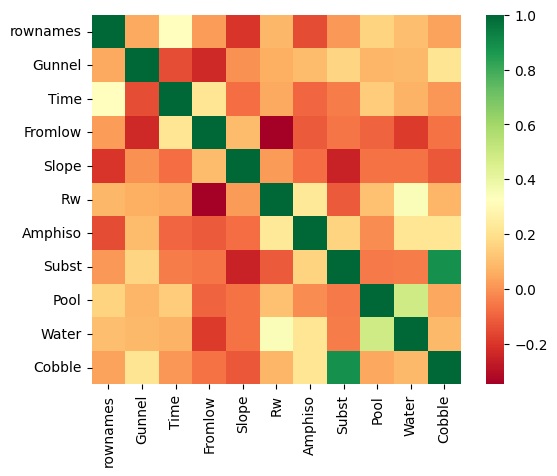

In [33]:
#plotting heatmap for overall data set
sns.heatmap(data.corr(), square=True, cmap='RdYlGn')

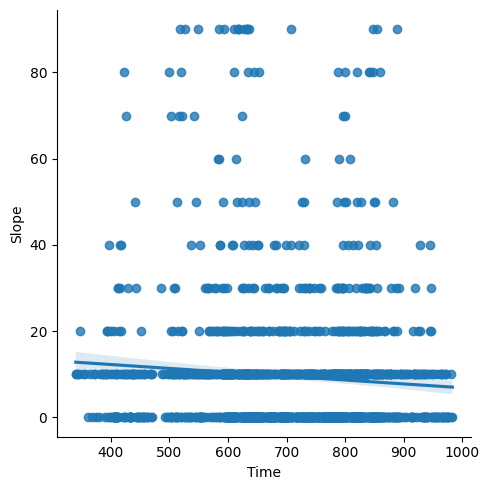

In [34]:
#We can use the lmplot 6. method from seaborn to see the relationship between RM and MEDV. Check out the following snippet:
sns.lmplot(x = 'Time', y = 'Slope', data = data)

In [35]:
#Now the final step is training the linear regression model. From the extremely powerful sklearn library, we import the LinearRegression() function to fit
#our training dataset to the model. When we run LinearRegression().fit(), the function automatically calculates the OLS, which we discussed earlier, and
#generates an appropriate line function:
#Training a Linear Regression Model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
# Fitting the training data to our model
regressor.fit(X_train, y_train)

LinearRegression()

In [36]:
#Model evaluation
#R^2 can be determined using our test dataset in the LinearRegression.score() method:
#check prediction score/accuracy
regressor.score(X_test, y_test)

0.061134288353554056

In [37]:
#Before that, let's predict the y values with our model and evaluate it more. And a target variables DataFrame is also built:
# predict the y values
y_pred=regressor.predict(X_test)
# a data frame with actual and predicted values of y
evaluate = pd.DataFrame({'Actual': y_test.values.flatten(),
'Predicted': y_pred.flatten()})
evaluate.head(10)

,Actual,Predicted
0,0,0.015465
1,0,0.006812
2,0,0.063908
3,0,0.017676
4,0,0.030019
5,0,0.022660
6,0,-0.023905
7,0,0.049760
8,0,0.082224
9,0,0.088410


<Axes: >

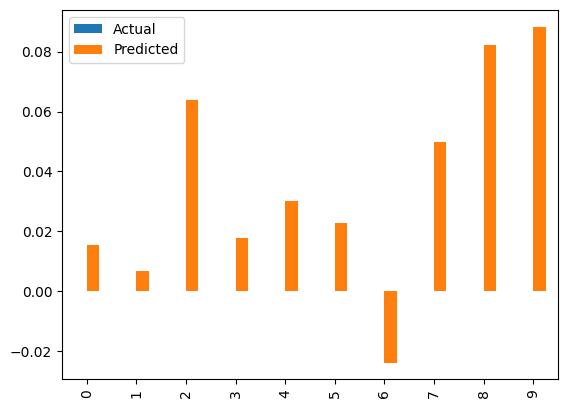

In [38]:
#The preceding screenshot shows the difference between the actual values and the predicted values. We can see them if we plot them:
evaluate.head(10).plot(kind = 'bar')

In [39]:
#Computing accuracy
# Scoring the model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# R2 Score
print(f"R2 score: {r2_score(y_test, y_pred)}")
# Mean Absolute Error (MAE)
print(f"MAE score: {mean_absolute_error(y_test, y_pred)}")
# Mean Squared Error (MSE)
print(f"MSE score: {mean_squared_error(y_test, y_pred)}")

R2 score: 0.061134288353554056
MAE score: 0.07240795976383939
MSE score: 0.028508908609265998
